## 1. Database Overview

This notebook builds a relational SQLite3 database from the cleaned Data Analyst job datasets prepared in Notebooks 01 and 02.

The project examines whether Data Analyst positions that require a degree differ from positions that do not require a degree in areas such as salary, employment type, remote work, location, and technical skill requirements.

The cleaned datasets are stored in two database tables:

* `degree_jobs` — Data Analyst job postings identified as requiring a degree.
* `no_degree_jobs` — Data Analyst job postings identified as not requiring a degree.

SQLite3 is used to store the cleaned data and perform SQL-based analysis. Separating the two populations into their own tables preserves the distinction that is central to the project's research question while allowing the datasets to be compared using SQL.

The database portion of the project demonstrates how cleaned Python/Pandas data can be transferred into a relational database and analyzed using SQL.


## 2. Load Cleaned Datasets

The cleaned Data Analyst job datasets generated in Notebooks 01 and 02 are loaded into this notebook for database creation and SQL analysis.

The two datasets represent separate populations:

* **Degree-required jobs:** Data Analyst positions identified as requiring a degree.
* **No-degree jobs:** Data Analyst positions identified as not requiring a degree.

The cleaned CSV files are loaded using relative paths so that the project remains portable across operating systems and can be reproduced from the repository.

The datasets will be stored as separate tables in the SQLite3 database and will be validated before the database is created.


In [45]:
# Load cleaned datasets
import pandas as pd
import numpy
import matplotlib.pyplot as plt

degree_jobs = pd.read_csv("../data/degree_jobs_cleaned.csv")
no_degree_jobs = pd.read_csv("../data/no_degree_jobs_cleaned.csv")

## 3. Validate Dataset Compatibility

The cleaned degree-required and no-degree datasets were designed with a consistent analytical structure so they can be stored and compared within the same SQLite database.

Both datasets contain the same core job, salary, location, employment, date, and technical-skill fields. The primary difference is the population-specific field used to describe the degree requirement:

* `degree_type` is a string field in the `degree_jobs` table that identifies the type of degree requirement.
* `no_degree_mention` is a Boolean field in the `no_degree_jobs` table that identifies whether a no-degree designation was present.

Both datasets also contain `degree_flag`, which provides a standardized indicator for distinguishing the two populations.

The consistent structure allows the two tables to be analyzed and compared using SQL while preserving the information specific to each population.


In [46]:
degree_jobs.columns.tolist()
no_degree_jobs.columns.tolist()

['job_id',
 'job_title',
 'salary_usd',
 'company_location',
 'is_remote',
 'employee_location',
 'job_skills',
 'no_degree_mention',
 'posting_date',
 'company_name',
 'has_python',
 'has_sql',
 'has_tableau',
 'degree_flag',
 'salary_tier',
 'employment_type']

In [47]:
print("Degree jobs columns:")
print(degree_jobs.columns.tolist())

Degree jobs columns:
['job_id', 'job_title', 'salary_usd', 'employment_type', 'company_location', 'is_remote', 'employee_location', 'job_skills', 'degree_type', 'posting_date', 'company_name', 'has_python', 'has_sql', 'has_tableau', 'degree_flag', 'salary_tier']


In [48]:
print("No-degree jobs columns:")
print(no_degree_jobs.columns.tolist())

No-degree jobs columns:
['job_id', 'job_title', 'salary_usd', 'company_location', 'is_remote', 'employee_location', 'job_skills', 'no_degree_mention', 'posting_date', 'company_name', 'has_python', 'has_sql', 'has_tableau', 'degree_flag', 'salary_tier', 'employment_type']


In [49]:
degree_jobs.shape

(759, 16)

In [50]:
no_degree_jobs.shape

(18294, 16)

In [51]:
degree_jobs['job_id'].is_unique, no_degree_jobs['job_id'].is_unique

(True, True)

## 4. Database Design

### Why Two Tables?

The database uses two tables to represent the two populations at the center of this project: Data Analyst jobs that require a degree and Data Analyst jobs that do not require a degree.

Keeping these populations in separate tables preserves the distinction established during the data-cleaning process while allowing their characteristics to be analyzed and compared using SQL.

The two tables share the same core analytical structure, including job information, salary information, company and location data, employment information, remote-work status, posting date, and technical skill indicators. Each table also contains a population-specific field describing its degree classification.

### `degree_jobs`

The `degree_jobs` table contains cleaned Data Analyst job postings identified as requiring a degree.

The table includes the `degree_type` field, which records the type of degree requirement identified during the data-cleaning process.

### `no_degree_jobs`

The `no_degree_jobs` table contains cleaned Data Analyst job postings identified as not requiring a degree.

The table includes the `no_degree_mention` Boolean field, which indicates whether the job posting was identified as a no-degree position.

### Primary Keys

Each table uses `job_id` as its primary key.

`job_id` uniquely identifies each job record within its respective table and was established during the data-cleaning process after duplicate records were removed.

The `job_id` values are independent between the two tables. They identify individual records within each population and do not represent a relationship between `degree_jobs` and `no_degree_jobs`.

Therefore, the two tables are designed as separate populations within the same relational database rather than as tables connected through a foreign-key relationship.

This structure allows SQL queries to analyze each population independently and compare the results across degree requirements.

## 5. Create SQLite Database

The cleaned Data Analyst job datasets will be stored in a SQLite3 relational database. SQLite3 was selected because it provides a lightweight relational database system that can be created and queried directly from Python without requiring a separate database server.

The database will contain two tables:

* `degree_jobs`
* `no_degree_jobs`

Each table will use `job_id` as its primary key. The tables will remain independent because their `job_id` values identify records within their respective populations and do not represent relationships between the two datasets.

The database will be created using Python's built-in `sqlite3` module, and the cleaned Pandas DataFrames will be loaded into the database for subsequent SQL analysis.

The SQLite database connection has been established. The two cleaned Pandas DataFrames will now be written to the database as separate relational tables.

Each DataFrame will become its corresponding table:

* `degree_jobs`
* `no_degree_jobs`

The `job_id` column will be retained as the unique record identifier for each table. The cleaned data will be loaded without replacing or modifying the values established during the data-cleaning notebooks.

### Define Primary Keys

The initial database load successfully created both tables and transferred all cleaned records. Schema validation showed that `job_id` was stored as an `INTEGER`, but SQLite had not assigned it an explicit primary-key constraint.

Because `job_id` uniquely identifies each record within its respective dataset, the tables will be recreated with `job_id` explicitly defined as the primary key. This ensures that the database structure matches the relational design established earlier.

The cleaned Pandas DataFrames remain unchanged and will be reloaded after the tables are recreated.

### Database Validation

The SQLite database was validated after the cleaned datasets were loaded. The `degree_jobs` table contains 759 records, while the `no_degree_jobs` table contains 18,294 records, for a combined total of 19,053 records.

The `job_id` column is defined as the primary key in both tables, and the number of unique `job_id` values matches the total number of records in each table. This confirms that the database contains the expected records and that each record has a unique identifier within its respective table.

The database is now ready for further structural documentation and SQL analysis.


In [52]:
import sqlite3
conn = sqlite3.connect("../data/data_analyst_jobs.db")
conn

In [53]:
# Remove the initially created tables
conn.execute("DROP TABLE IF EXISTS degree_jobs")
conn.execute("DROP TABLE IF EXISTS no_degree_jobs")

conn.commit()

In [54]:
conn.execute("""
CREATE TABLE degree_jobs (
    job_id INTEGER PRIMARY KEY,
    job_title TEXT,
    salary_usd INTEGER,
    company_location TEXT,
    is_remote INTEGER,
    employee_location TEXT,
    job_skills TEXT,
    degree_type TEXT,
    posting_date TEXT,
    company_name TEXT,
    has_python INTEGER,
    has_sql INTEGER,
    has_tableau INTEGER,
    degree_flag INTEGER,
    salary_tier TEXT,
    employment_type TEXT
)
""")


In [55]:
conn.execute("""
CREATE TABLE no_degree_jobs (
    job_id INTEGER PRIMARY KEY,
    job_title TEXT,
    salary_usd REAL,
    company_location TEXT,
    is_remote INTEGER,
    employee_location TEXT,
    job_skills TEXT,
    no_degree_mention INTEGER,
    posting_date TEXT,
    company_name TEXT,
    has_python INTEGER,
    has_sql INTEGER,
    has_tableau INTEGER,
    degree_flag INTEGER,
    salary_tier TEXT,
    employment_type TEXT
)
""")

In [56]:
conn.commit()

In [57]:
# Verify tables
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,degree_jobs
1,no_degree_jobs


In [58]:
degree_jobs_db = degree_jobs.copy()
no_degree_jobs_db = no_degree_jobs.copy()

degree_jobs_db["job_skills"] = degree_jobs_db["job_skills"].apply(str)
no_degree_jobs_db["job_skills"] = no_degree_jobs_db["job_skills"].apply(str)

In [59]:
degree_jobs_db.to_sql(
    "degree_jobs",
    conn,
    if_exists="append",
    index=False
)

no_degree_jobs_db.to_sql(
    "no_degree_jobs",
    conn,
    if_exists="append",
    index=False
)

18294

In [60]:
# Validate SQLite schema
pd.read_sql_query(
    "PRAGMA table_info(degree_jobs);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,job_id,INTEGER,0,None,1
1,1,job_title,TEXT,0,None,0
2,2,salary_usd,INTEGER,0,None,0
3,3,company_location,TEXT,0,None,0
4,4,is_remote,INTEGER,0,None,0
5,5,employee_location,TEXT,0,None,0
6,6,job_skills,TEXT,0,None,0
7,7,degree_type,TEXT,0,None,0
8,8,posting_date,TEXT,0,None,0
9,9,company_name,TEXT,0,None,0


In [61]:
# Validate SQLite schema
pd.read_sql_query(
    "PRAGMA table_info(no_degree_jobs);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,job_id,INTEGER,0,None,1
1,1,job_title,TEXT,0,None,0
2,2,salary_usd,REAL,0,None,0
3,3,company_location,TEXT,0,None,0
4,4,is_remote,INTEGER,0,None,0
5,5,employee_location,TEXT,0,None,0
6,6,job_skills,TEXT,0,None,0
7,7,no_degree_mention,INTEGER,0,None,0
8,8,posting_date,TEXT,0,None,0
9,9,company_name,TEXT,0,None,0


In [62]:
pd.read_sql_query(
    """
    SELECT
        (SELECT COUNT(*) FROM degree_jobs) AS degree_jobs_count,
        (SELECT COUNT(*) FROM no_degree_jobs) AS no_degree_jobs_count;
    """,
    conn
)

,degree_jobs_count,no_degree_jobs_count
0,759,18294


In [63]:
pd.read_sql_query(
    """
    SELECT
        'degree_jobs' AS table_name,
        COUNT(*) AS total_rows,
        COUNT(DISTINCT job_id) AS unique_job_ids
    FROM degree_jobs

    UNION ALL

    SELECT
        'no_degree_jobs' AS table_name,
        COUNT(*) AS total_rows,
        COUNT(DISTINCT job_id) AS unique_job_ids
    FROM no_degree_jobs;
    """,
    conn
)

,table_name,total_rows,unique_job_ids
0,degree_jobs,759,759
1,no_degree_jobs,18294,18294


## 6. Entity-Relationship Diagram

The Entity-Relationship Diagram (ERD) represents the structure of the SQLite database and shows the two tables used to store the cleaned Data Analyst job datasets.

The database contains two independent tables:

* `degree_jobs` — job postings associated with a degree requirement.
* `no_degree_jobs` — job postings that do not mention a degree requirement.

Both tables use `job_id` as their primary key. The primary keys uniquely identify records within their respective tables.

The two tables do not have a foreign-key relationship because they represent separate populations of job postings. Although the tables share many analytical fields, their `job_id` values identify records independently and are not used to connect records between the tables.

The ERD therefore documents two independent entities with their respective primary keys and attributes.

![Data Analyst Jobs Entity-Relationship Diagram](../images/data_analyst_jobs_erd.png)

## 7. SQL Analysis & Visualization

The cleaned Data Analyst job datasets are now stored in SQLite3 and will be analyzed using SQL queries. The SQL analysis is designed to address the project's research questions while demonstrating intermediate and advanced SQL techniques.

The analysis will compare degree-required and no-degree-mentioned Data Analyst positions across job volume, salary, employment characteristics, and technical skill requirements.

Three SQL queries will be used to demonstrate different relational database techniques, including aggregation, conditional logic, `UNION ALL`, `GROUP BY`, `HAVING`, common table expressions (CTEs), and subqueries where appropriate.

The following visualizations are created from the SQLite query results. Each chart supports the SQL findings by showing differences between degree-required postings and postings with an explicit no-degree mention.

### Query 1: Average Salary by Degree Requirement

This query compares the average reported salary between degree-required and no-degree-mentioned Data Analyst positions.

The query uses `UNION ALL` to combine results from the two independent SQLite tables. `COUNT(salary_usd)` counts the number of job postings with a reported salary, while `AVG(salary_usd)` calculates the average reported salary for each population.

Because `salary_usd` contains missing values, `COUNT(salary_usd)` is used to show the number of salary observations contributing to each average. SQL aggregation functions ignore `NULL` values when calculating these results.

Including the number of reported salaries provides important context when comparing the two populations, particularly because the no-degree-mentioned dataset contains substantially more missing salary values.

The results will be used in Notebook 04 to create a bar chart comparing average reported salary by degree requirement.

In [64]:
query_1 = """
SELECT
    'Degree Required' AS degree_requirement,
    COUNT(salary_usd) AS jobs_with_salary,
    ROUND(AVG(salary_usd), 0) AS average_salary
FROM degree_jobs

UNION ALL

SELECT
    'No Degree Mentioned' AS degree_requirement,
    COUNT(salary_usd) AS jobs_with_salary,
    ROUND(AVG(salary_usd), 0) AS average_salary
FROM no_degree_jobs;
"""

query_1_results = pd.read_sql_query(query_1, conn)

query_1_results

,degree_requirement,jobs_with_salary,average_salary
0,Degree Required,759,111321.0
1,No Degree Mentioned,345,87477.0


#### Interpretation

The results show that Data Analyst positions requiring a degree had a higher average reported salary ($111,321) than positions where no degree was mentioned ($87,476).

However, the two averages are based on substantially different numbers of reported salaries. All 759 degree-required postings contain a reported salary, while only 345 of the 18,294 no-degree-mentioned postings contain salary information.

Therefore, this comparison describes the reported salaries in each population but should not be interpreted as evidence that a degree requirement directly causes higher salaries. The substantial difference in salary reporting between the two datasets is an important limitation of the comparison.

### Visualization 1 — Average Salary by Degree Requirement

This bar chart compares the average reported salary for data analyst job postings based on whether a degree requirement was mentioned. The visualization uses the results from Query 1 to make the difference in average salary between the two groups easier to compare.

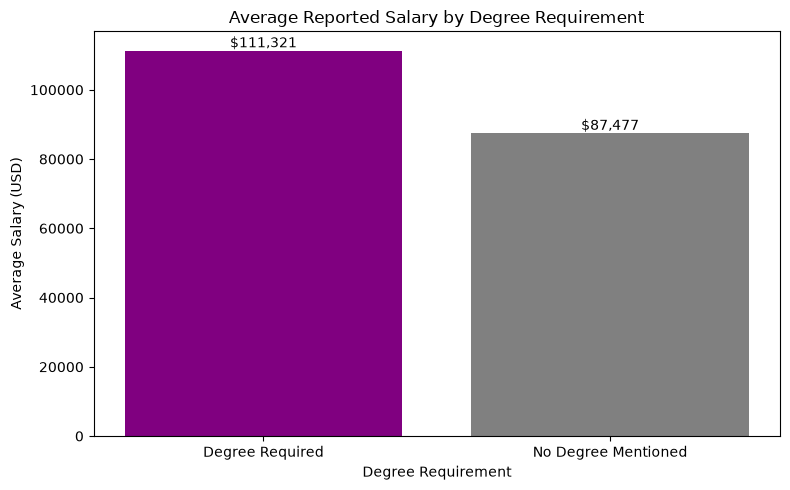

In [65]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    query_1_results["degree_requirement"],
    query_1_results["average_salary"],
    color=["#800080", "#808080"]
)

plt.title("Average Reported Salary by Degree Requirement")
plt.xlabel("Degree Requirement")
plt.ylabel("Average Salary (USD)")

plt.bar_label(
    bars,
    labels=[f"${value:,.0f}" for value in query_1_results["average_salary"]]
)

plt.tight_layout()
plt.show()

### Query 2: Average Salary by Employment Type and Degree Requirement

This query examines whether the difference in average reported salary between degree-required and no-degree-mentioned positions varies by employment type.

The two tables are combined using `UNION ALL` within a common table expression (CTE). The shared `degree_flag` column is used to identify whether each position belongs to the degree-required or no-degree-mentioned population.

A `CASE` expression converts the Boolean degree flag into descriptive categories. The results are grouped by degree requirement and employment type, allowing average reported salaries to be compared across employment categories.

Records with missing employment types are excluded from the comparison, while missing salary values are automatically excluded from the `AVG()` calculation. The number of reported salaries is included to show how many observations contribute to each average.

In [66]:
query_2 = """
WITH all_jobs AS (
    SELECT
        degree_flag,
        employment_type,
        salary_usd
    FROM degree_jobs

    UNION ALL

    SELECT
        degree_flag,
        employment_type,
        salary_usd
    FROM no_degree_jobs
)

SELECT
    CASE
        WHEN degree_flag = 1 THEN 'Degree Required'
        ELSE 'No Degree Mentioned'
    END AS degree_requirement,
    employment_type,
    COUNT(salary_usd) AS jobs_with_salary,
    CAST(ROUND(AVG(salary_usd), 0) AS INTEGER) AS average_salary
FROM all_jobs
WHERE employment_type IS NOT NULL
GROUP BY degree_flag, employment_type
ORDER BY degree_flag, employment_type;
"""

query_2_results = pd.read_sql_query(query_2, conn)

query_2_results

,degree_requirement,employment_type,jobs_with_salary,average_salary
0,No Degree Mentioned,CT,20,85425.0
1,No Degree Mentioned,FT,325,87603.0
2,No Degree Mentioned,PT,0,NaN
3,Degree Required,CT,190,115618.0
4,Degree Required,FL,185,110021.0
5,Degree Required,FT,186,111692.0
6,Degree Required,PT,198,108064.0


#### Interpretation

The results show that degree-required positions had higher average reported salaries than no-degree-mentioned positions across every employment type where both groups had reported salary data.

Among degree-required positions, average reported salaries ranged from $108,064 for part-time positions to $115,618 for contract positions. In the no-degree-mentioned dataset, reported salaries were available only for contract and full-time positions, with averages of $85,425 and $87,603 respectively.

The no-degree-mentioned part-time group contained 289 positions, but none had a reported salary. As a result, no average salary could be calculated for this group.

These results suggest that the salary difference observed in Query 1 persists across the employment types with available salary data. However, the limited salary reporting in the no-degree-mentioned dataset remains an important limitation when interpreting these comparisons.

## 2. Visualization 2: Average Salary by Employment Type and Degree Requirement

The second visualization presents the results of SQL Query 2, comparing average reported salaries across employment types for Data Analyst positions by degree requirement.

A grouped bar chart is used to compare the average salaries of degree-required and no-degree-mentioned positions within each employment type.

Missing salary values are excluded from the visualization because they do not represent an available salary estimate.

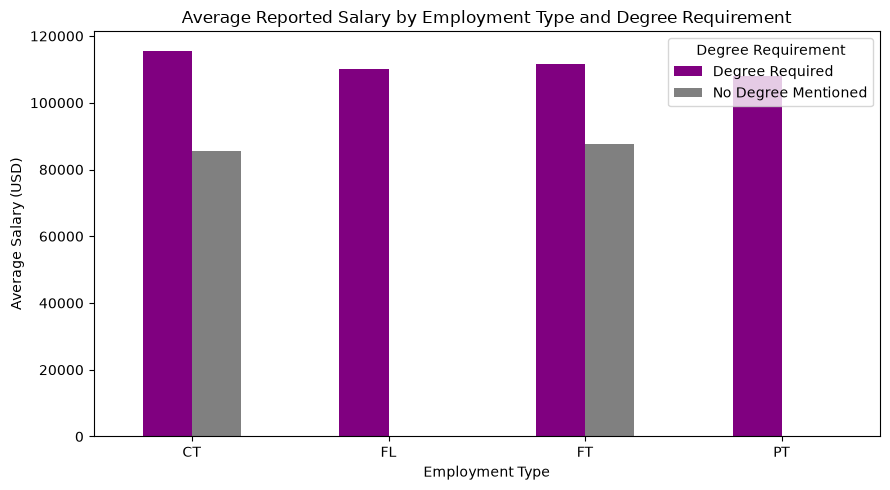

In [67]:
plot_data = query_2_results.pivot(
    index="employment_type",
    columns="degree_requirement",
    values="average_salary"
)

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#800080", "#808080"]
)

plt.title("Average Reported Salary by Employment Type and Degree Requirement")
plt.xlabel("Employment Type")
plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=0)
plt.legend(title="Degree Requirement")

plt.tight_layout()
plt.show()

### Query 3: Average Salary by Technical Skill and Degree Requirement

This query examines the average reported salary for Data Analyst positions that identify Python, SQL, or Tableau as a required skill.

The query uses `UNION ALL` to combine results from the degree-required and no-degree-mentioned tables. Each skill is evaluated separately using the corresponding skill indicator column (`has_python`, `has_sql`, or `has_tableau`).

Only job postings with both the specified skill and a reported `salary_usd` value are included in each calculation. `AVG()` is used to calculate the average reported salary for each skill and degree requirement.

This analysis allows the average reported salary associated with selected technical skills to be compared between degree-required and no-degree-mentioned positions.

In [68]:
query_3 = """
SELECT
    'Degree Required' AS degree_requirement,
    'Python' AS skill,
    CAST(ROUND(AVG(salary_usd), 0) AS INTEGER) AS average_salary
FROM degree_jobs
WHERE has_python = 1
  AND salary_usd IS NOT NULL

UNION ALL

SELECT
    'Degree Required',
    'SQL',
    CAST(ROUND(AVG(salary_usd), 0) AS INTEGER)
FROM degree_jobs
WHERE has_sql = 1
  AND salary_usd IS NOT NULL

UNION ALL

SELECT
    'Degree Required',
    'Tableau',
    CAST(ROUND(AVG(salary_usd), 0) AS INTEGER)
FROM degree_jobs
WHERE has_tableau = 1
  AND salary_usd IS NOT NULL

UNION ALL

SELECT
    'No Degree Mentioned',
    'Python',
    CAST(ROUND(AVG(salary_usd), 0) AS INTEGER)
FROM no_degree_jobs
WHERE has_python = 1
  AND salary_usd IS NOT NULL

UNION ALL

SELECT
    'No Degree Mentioned',
    'SQL',
    CAST(ROUND(AVG(salary_usd), 0) AS INTEGER)
FROM no_degree_jobs
WHERE has_sql = 1
  AND salary_usd IS NOT NULL

UNION ALL

SELECT
    'No Degree Mentioned',
    'Tableau',
    CAST(ROUND(AVG(salary_usd), 0) AS INTEGER)
FROM no_degree_jobs
WHERE has_tableau = 1
  AND salary_usd IS NOT NULL

ORDER BY skill, degree_requirement;
"""

query_3_results = pd.read_sql_query(query_3, conn)

query_3_results

,degree_requirement,skill,average_salary
0,Degree Required,Python,113110
1,No Degree Mentioned,Python,94457
2,Degree Required,SQL,112272
3,No Degree Mentioned,SQL,90379
4,Degree Required,Tableau,107252
5,No Degree Mentioned,Tableau,92296


#### Interpretation

The results show that degree-required Data Analyst positions had higher average reported salaries than no-degree-mentioned positions for all three technical skills examined.

Among degree-required positions, Python had the highest average reported salary at $113,110, followed by SQL at $112,272 and Tableau at $107,252. Among no-degree-mentioned positions, Python had the highest average at $94,457, followed by Tableau at $92,296 and SQL at $90,379.

The largest salary difference occurred among positions requiring SQL, with a difference of $21,893 between the two populations. The smallest difference occurred among Tableau-related positions, at $14,956.

These results describe salary differences among postings that mention each skill and should not be interpreted as evidence that a particular technical skill or degree requirement causes higher salaries. A single job posting may include multiple technical skills, and the analysis is limited to postings with reported salary information.

## 3. Visualization 3: Average Salary by Technical Skill and Degree Requirement

The third visualization presents the results of SQL Query 3, comparing average reported salaries for Data Analyst positions associated with Python, SQL, and Tableau skills.

A grouped bar chart is used to compare the average salary associated with each technical skill across degree-required and no-degree-mentioned positions.

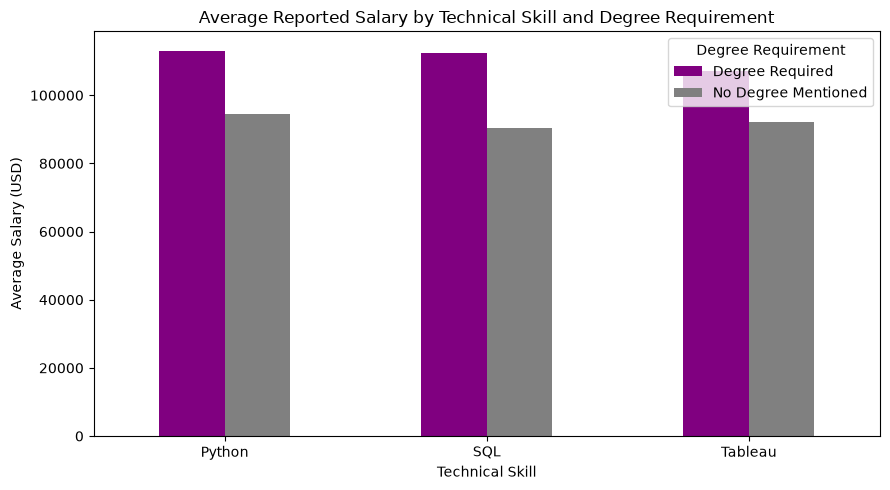

In [69]:
plot_data = query_3_results.pivot(
    index="skill",
    columns="degree_requirement",
    values="average_salary"
)

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#800080", "#808080"]
)

plt.title("Average Reported Salary by Technical Skill and Degree Requirement")
plt.xlabel("Technical Skill")
plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=0)
plt.legend(title="Degree Requirement")

plt.tight_layout()
plt.show()